In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
# global_path = "/Users/edabier/Documents/Thèse/Thèse_Télécom"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

Using device: cuda:0


In [11]:
dataset = "apex"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

features: torch.Size([1024, 196])


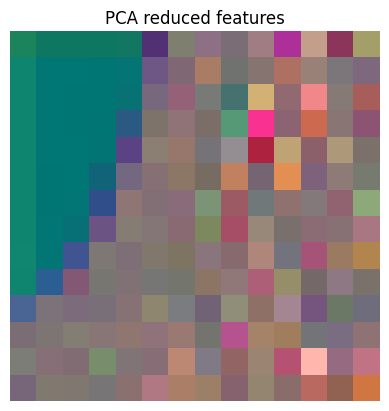

In [12]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

with torch.no_grad():
    _, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")
plots.plot_pca_features(features)

In [13]:
# mses, sads = [], []
# for k in tqdm(range(5)):
#     n_xp = 15
#     E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
#     loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

#     for i in range(n_xp):
#         # print(f"training {i+1}/{n_xp}")

#         model = unmx.UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=1, kernel_size=1)
#         model.apply(model.weights_init)
#         model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

#         epochs, lr = 200, 0.002
#         optim_wrapper = dict(
#             optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
#             constructor='LayerDecayOptimizerConstructor_ViT',
#             paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
#         optimizer = build_optim_wrapper(model, optim_wrapper)

#         for _ in range(epochs):

#             for Y, _, _ in loader:
            
#                 optimizer.zero_grad()

#                 Y = utils.oneD_to_2d(Y).to(dev)

#                 _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
#                 Y_fm = rsfm.reshape_Y(fm_name, Y, new_H)

#                 E_hat, A_hat, Y_hat = model(features)

#                 loss = model.loss(Y_fm, Y_hat, A_hat, E_hat, W_tv_e=0)
#                 loss.backward()
#                 nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#                 optimizer.step()
                
#                 with torch.no_grad():
#                     constraints = models.weightConstraint()
#                     model.decoder.apply(constraints)
        
#         model.eval()
        
#         with torch.no_grad():
            
#             _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
#             Y_fm, A_init_fm = rsfm.reshape_Y(fm_name, Y, new_H, A_init)
#             E_hat, A_hat, _ = model(features)

#         E_hats[i] = E_hat
#         A_hats[i] = A_hat.squeeze(0)

#     E_hat_m = torch.mean(E_hats, dim=0)
#     A_hat_m = torch.mean(A_hats, dim=0)
#     sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_A=False, plot_E=False)
#     # print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
#     print(sad, mse)
#     mses.append(mse)
#     sads.append(sad)
# # torch.save(A_hat_m, f"{global_path}/SOTA_results/HyperSL/{dataset}_A.pt")
# # torch.save(E_hat_m, f"{global_path}/SOTA_results/HyperSL/{dataset}_E.pt")
# print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")

In [ ]:
import time
start = time.time()
features=features.unsqueeze(0)

n_xp = 10
mses, sads = [], []
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    # model = unmx.HyperSLUnmixer(D=D, alpha=alpha, H=new_H, B=B, c=c)
    model = unmx.UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=1, kernel_size=1)
    # model = unmx.UnmixingFromUpFeat(D=D, B=B, c=c, H=new_H)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y(fm_name, Y, new_H)

            E_hat, A_hat, Y_hat = model(features)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat, W_tv_e=0)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
    
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y(fm_name, Y, new_H, A_init)
        E_hat, A_hat, _ = model(features)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)
        
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")
plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init)
# torch.save(A_hat[0], f"{global_path}/SOTA_results/{fm_name}/{dataset}_A.pt")
# torch.save(E_hat, f"{global_path}/SOTA_results/{fm_name}/{dataset}_E.pt")
print((time.time()-start)/10)

In [4]:
# import os
# import rasterio

# path = f"{global_path}/datasets/enmap/hsis"
# with rasterio.open(path + "/" + os.listdir(path)[0]) as img:
#     Y_init = torch.from_numpy(img.read()).to(dtype=torch.float, device=dev).unsqueeze(0)

# wavelengths_path = f"{global_path}/datasets/enmap/spectralearth_wavelength.txt"
# with open(wavelengths_path, "r") as file:
#     lines = file.readlines()
#     wavelengths = [float(line.strip()) for line in lines if line.strip()]

# fm, Y_init_f, new_H = rsfm.create_fm("Panopticon", Y_init, path=global_path)
# _, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)
# features = utils.oneD_to_2d(features)
# D, alpha, _ = features.shape

# for p in os.listdir(path):
#     with rasterio.open(path + "/" + p) as img:

#         im_name = p[:-4]
#         Y = torch.from_numpy(img.read()).to(dtype=torch.float, device=dev)
#         _, features_hr = rsfm.extract_f(fm, utils.standardise(Y).unsqueeze(0), new_H, wavelengths)
#         features_lr = F.interpolate(utils.oneD_to_2d(features_hr).unsqueeze(0), size=(alpha//2, alpha//2))

#         torch.save(features_hr, f"{global_path}/datasets/enmap/features_hr_Panopticon/{im_name}.pt")
#         torch.save(features_lr, f"{global_path}/datasets/enmap/features_lr_Panopticon/{im_name}.pt")

training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.551, NMSE = 0.288
training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.555, NMSE = 0.322
training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.557, NMSE = 0.358
training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.553, NMSE = 0.311
training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.559, NMSE = 0.409
training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.558, NMSE = 0.424
training 7/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.558, NMSE = 0.326

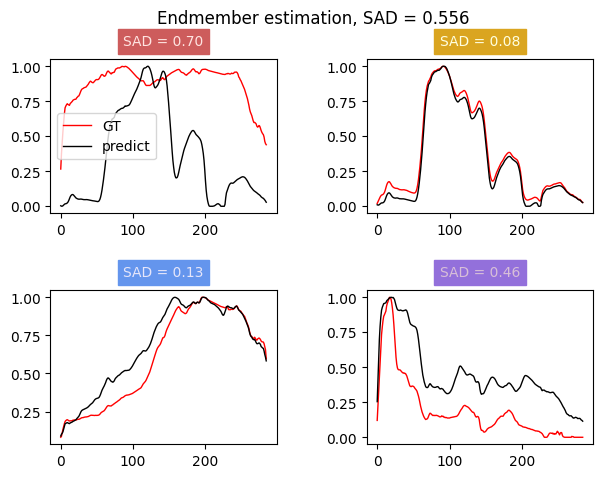

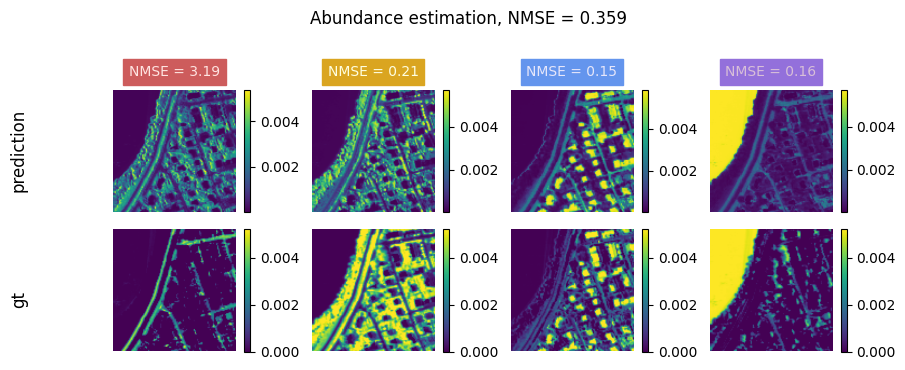

In [ ]:
import time
start = time.time()
features=features.unsqueeze(0)

"""Linear upsampling of feature"""

n_xp = 15
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    # model = unmx.HyperSLUnmixer(D=D, alpha=alpha, H=new_H, B=B, c=c)
    model = unmx.UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=1, kernel_size=1)
    # model = unmx.UnmixingFromUpFeat(D=D, B=B, c=c, H=new_H)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            # _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y(fm_name, Y, new_H)

            E_hat, A_hat, Y_hat = model(features)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
    
    model.eval()
    
    with torch.no_grad():
        
        # _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y(fm_name, Y, new_H, A_init)
        E_hat, A_hat, _ = model(features)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")
# torch.save(A_hat[0], f"{global_path}/SOTA_results/HyperSL/{dataset}_A.pt")
# torch.save(E_hat, f"{global_path}/SOTA_results/HyperSL/{dataset}_E.pt")
print((time.time()-start)*60)

training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.317, NMSE = 1.027
Average SAD = 0.2296 ± 0.129, NMSE = 0.6025 ± 0.434


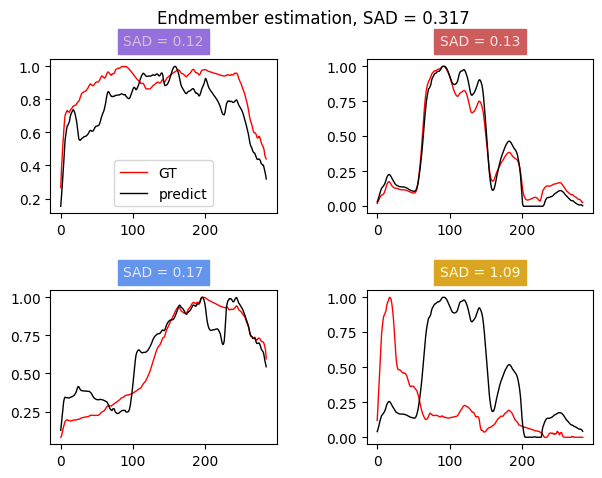

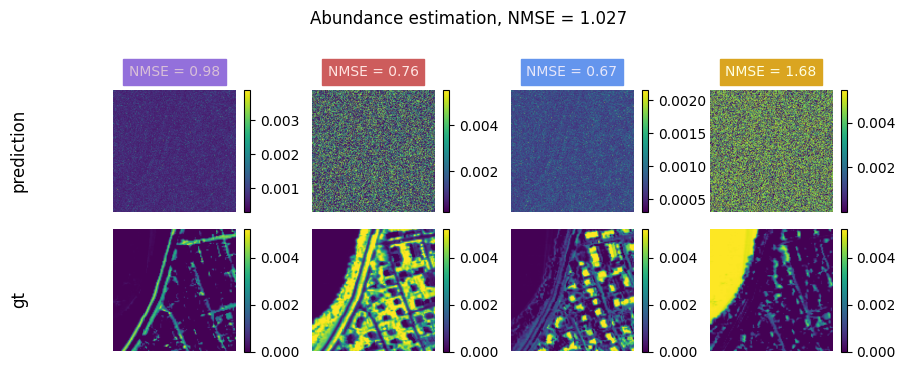

In [ ]:
"""Linear upsampling of feature"""

loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampler_weight = torch.mean(upsampler_weights, dim=0)

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, upsampler="Linear", n_features=1, kernel_size=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)
    model.upsample.weights = upsampler_weight
    for param in model.upsample.parameters():
        param.requires_grad = False

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            Y_n = utils.standardise(Y)

            _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)

            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
    
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
        E_hat, A_hat, _ = model(features, Y_fm)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

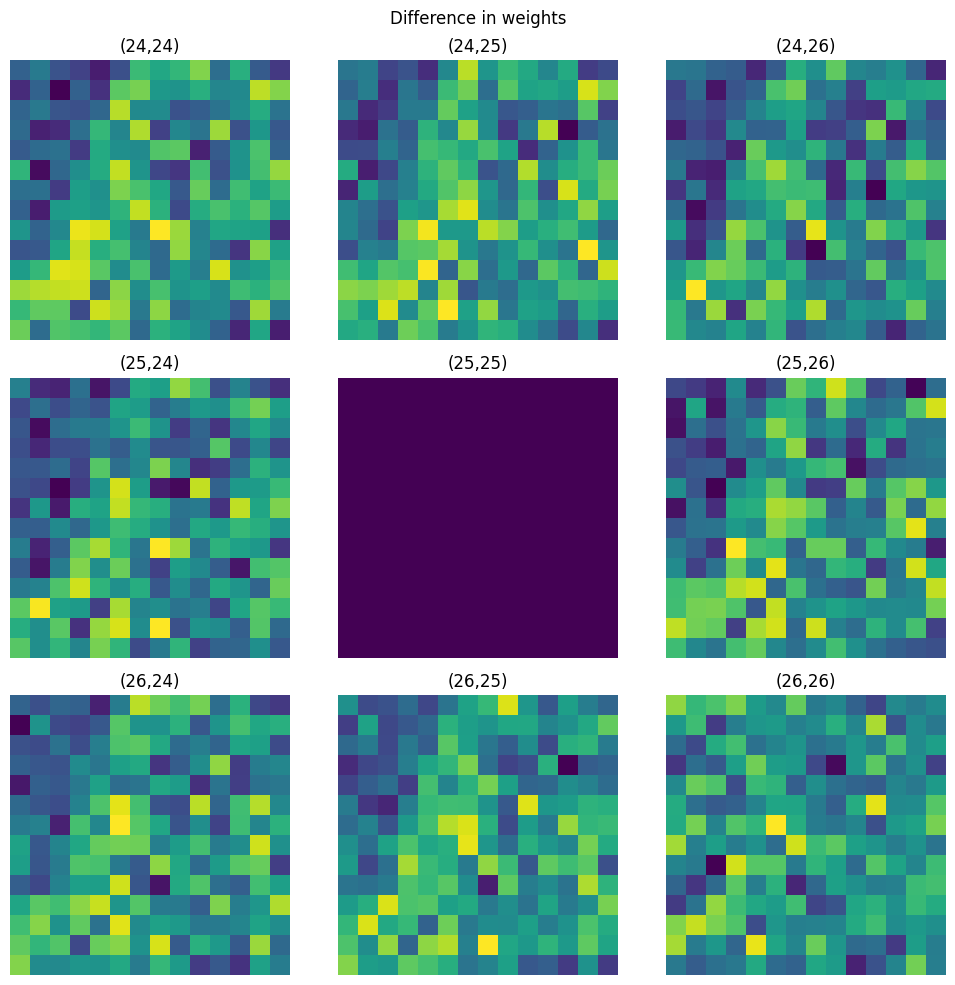

Average MSE in weights compared to pixel (25, 25) and a neighborhood of size 3 0.015146723613725044


In [12]:
def compute_local_mse(W, i, j, neighborhood_size=3):
    W = W.reshape(int(W.shape[0]**0.5), int(W.shape[0]**0.5), int(W.shape[1]**0.5), int(W.shape[1]**0.5))
    h, w, _, _ = W.shape
    mse_values = []

    # Define neighborhood (e.g., 3x3 around (i,j))
    for di in range(-neighborhood_size//2, neighborhood_size//2 + 1):
        for dj in range(-neighborhood_size//2, neighborhood_size//2 + 1):
            ni, nj = i + di, j + dj
            if 0 <= ni < h and 0 <= nj < w:  # Stay within bounds
                # Compute MSE between W[i,j] and W[ni,nj]
                mse = torch.mean((W[i, j] - W[ni, nj]) ** 2).item()
                mse_values.append(mse)

    return np.mean(mse_values)

def plot_weight_differences(W, i, j, neighborhood_size=3):
    W = W.reshape(int(W.shape[0]**0.5), int(W.shape[0]**0.5), int(W.shape[1]**0.5), int(W.shape[1]**0.5))
    h, w, _, _ = W.shape
    fig, axes = plt.subplots(neighborhood_size, neighborhood_size, figsize=(10, 10))

    for di in range(-neighborhood_size//2, neighborhood_size//2 + 1):
        for dj in range(-neighborhood_size//2, neighborhood_size//2 + 1):
            ni, nj = i + di, j + dj
            if 0 <= ni < h and 0 <= nj < w:
                diff = (W[i, j] - W[ni, nj]).detach().cpu()
                ax = axes[di + neighborhood_size//2, dj + neighborhood_size//2]
                im = ax.imshow(diff)
                ax.set_title(f"({ni},{nj})")
                ax.axis("off")

    plt.suptitle(f"Difference in weights")
    plt.tight_layout()
    plt.show()

i, j = 25, 25
neighborhood_size = 3
W = model.upsample.weight
plot_weight_differences(W, i, j, neighborhood_size=neighborhood_size)
avg_mse = compute_local_mse(W, i, j, neighborhood_size=neighborhood_size)
print(f"Average MSE in weights compared to pixel {i,j} and a neighborhood of size {neighborhood_size}", avg_mse)

In [ ]:
# import os
# import rasterio

# path = f"{global_path}/datasets/enmap/hsis"
# with rasterio.open(path + "/" + os.listdir(path)[0]) as img:
#     Y_init = torch.from_numpy(img.read()).to(dtype=torch.float, device=dev).unsqueeze(0)

# wavelengths_path = f"{global_path}/datasets/enmap/spectralearth_wavelength.txt"
# with open(wavelengths_path, "r") as file:
#     lines = file.readlines()
#     wavelengths = [float(line.strip()) for line in lines if line.strip()]

# fm, Y_init_f, new_H = rsfm.create_fm("SpecAware", Y_init, path=global_path)
# _, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)
# features = utils.oneD_to_2d(features)
# D, alpha, _ = features.shape

# for p in os.listdir(path):
#     with rasterio.open(path + "/" + p) as img:

#         im_name = p[:-4]
#         Y = torch.from_numpy(img.read()).to(dtype=torch.float, device=dev)
#         _, features_hr = rsfm.extract_f(fm, utils.standardise(Y).unsqueeze(0), new_H, wavelengths)
#         features_lr = F.interpolate(utils.oneD_to_2d(features_hr).unsqueeze(0), size=(alpha//2, alpha//2))

#         torch.save(features_hr, f"{global_path}/datasets/enmap/features_hr_specaware/{im_name}.pt")
#         torch.save(features_lr, f"{global_path}/datasets/enmap/features_lr_specaware/{im_name}.pt")

In [ ]:
""" 10 times 15 trainings averaged"""

n_xp = 10
mses, sads = [], []
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp):
    print(f"Xp {i+1}/{n_xp}")
    n_train=15
    E_hats, A_hats = torch.zeros(n_train, B, c), torch.zeros(n_train, c, new_H, new_H)
    
    for k in range(n_train):
        print(f"training {k+1}/{n_train}")

        model = unmx.UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, upsampler="Features_fusion", n_features=1)
        model.apply(model.weights_init)
        model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

        epochs, lr = 200, 0.002
        optim_wrapper = dict(
            optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
            constructor='LayerDecayOptimizerConstructor_ViT',
            paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
        optimizer = build_optim_wrapper(model, optim_wrapper)

        for _ in range(epochs):

            for Y, _, _ in loader:
            
                optimizer.zero_grad()

                Y = utils.oneD_to_2d(Y).to(dev)
                Y_n = utils.standardise(Y)

                _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
                Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)

                E_hat, A_hat, Y_hat = model(features, Y_fm)

                loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
                optimizer.step()
                
                with torch.no_grad():
                    constraints = models.weightConstraint()
                    model.decoder.apply(constraints)
                    
        model.eval()
        
        with torch.no_grad():
            
            _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
            Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
            E_hat, A_hat, _ = model(features, Y_fm)
            E_hats[k] = E_hat
            A_hats[k] = A_hat.squeeze(0)

    E_hat_m = torch.mean(E_hats, dim=0)
    A_hat_m = torch.mean(A_hats, dim=0)
    sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_A=False, plot_E=False)
    sads.append(sad)
    mses.append(mse)        
    print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True)
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

Xp 1/10
training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 7/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 8/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 9/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 10

In [ ]:
# """Linear upsampling of abundances"""

# n_xp = 10
# mses, sads = [], []
# E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

# for i in range(n_xp): 
#     print(f"training {i}/{n_xp}")

#     model = unmx.UnmixingFromFeatures2(D=D, alpha=alpha, H=new_H, B=B, c=c)
#     model.apply(model.weights_init)
#     model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

#     epochs, lr = 200, 0.002
#     optim_wrapper = dict(
#         optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
#         constructor='LayerDecayOptimizerConstructor_ViT',
#         paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
#     optimizer = build_optim_wrapper(model, optim_wrapper)

#     flag = False
    
#     for _ in range(epochs):

#         for Y, _, _ in loader:
        
#             optimizer.zero_grad()

#             Y = utils.oneD_to_2d(Y).to(dev)

#             Y_fm, features = rsfm.extract_f(fm, Y, new_H, wavelengths)

#             E_hat, A_hat, Y_hat, A_hat_lr = model(features, Y_fm)
#             Y_hat_lr = model.decoder(A_hat_lr)
#             if E_hat.isnan().any():
#                 flag=True
#                 print("nan")
#                 break

#             loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)#, alpha, Y_hat_lr)

#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#             optimizer.step()
            
#             with torch.no_grad():
#                 constraints = models.weightConstraint()
#                 model.decoder.apply(constraints)
    
#     if not flag:
#         model.eval()
        
#         with torch.no_grad():
#             _, A_init_fm, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths, A_init)
            
#             E_hat, A_hat, _, A_hat_lr = model(features, Y_fm)
#             if E_hat.isnan().any():
#                 print("Nans during test")
#             sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
#             print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
#             mses.append(mse)
#             sads.append(sad)

#         E_hats[i] = E_hat
#         A_hats[i] = A_hat.squeeze(0)

# E_hat_m = torch.mean(E_hats, dim=0)
# A_hat_m = torch.mean(A_hats, dim=0)
# sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
# print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
# print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

In [ ]:
# """Linear upsampling of abundances from learned E_hat"""

# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

# model = unmx.UnmixingFromFeatures2(D=D, alpha=alpha, H=new_H, B=B, c=c)
# model.apply(model.weights_init)
# state_dict = model.decoder.state_dict()
# state_dict["decoder.weight"][:,:,0,0] = E_hat_m
# model.decoder.load_state_dict(state_dict)
# for param in model.decoder.parameters():
#     param.requires_grad = False

# epochs, lr = 200, 0.002
# optim_wrapper = dict(
#     optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
#     constructor='LayerDecayOptimizerConstructor_ViT',
#     paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
# optimizer = build_optim_wrapper(model, optim_wrapper)

# for _ in range(epochs):

#     for Y, _, _ in loader:
    
#         optimizer.zero_grad()

#         Y = utils.oneD_to_2d(Y).to(dev)

#         Y_fm, features = rsfm.extract_f(fm, Y, new_H, wavelengths)

#         E_hat, A_hat, Y_hat, A_hat_lr = model(features)
#         Y_hat_lr = model.decoder(A_hat_lr)

#         loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)#, alpha, Y_hat_lr)

#         loss.backward()
#         nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#         optimizer.step()
        
#         with torch.no_grad():
#             constraints = models.weightConstraint()
#             model.decoder.apply(constraints)
            
# model.eval()

# with torch.no_grad():
#     _, A_init_fm, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths, A_init)
#     E_hat, A_hat, _, A_hat_lr = model(features)
#     sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
#     # print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")